Outline of this file:
- sort enformer files by variable column (70% high, 15% low and 15% random)
  - expected number of enformer_class distribution:
    - file size: 5000
    - enformer_high: 0.7*5000 = 3500
    - enformer_low: 0.15*5000 = 750
    - enformer_random: 0.15*5000 = 750
  - cardiac singleton (DNase max)
    - enformer high : 4254.34
    - enformer random: 292.19
    - enformer low: 1.19
- combine with merged file
- plot class distribution

In [13]:
import pandas as pd 
import numpy as np
import random # for shuffle
import re 
import vcfpy
import os
import yaml

import seaborn as sns
import matplotlib.pyplot as plt

# config 
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()


sort_by = "DNase_max" 
enformer_matched_variant_dir = "/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants"
enformer_class_output_dir = "/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_enformer_class"
enformer_class_count_merged_output_dir = "/home/kisa/coding/80K_MPRA/enformer_data/enformer_counts_merged"

In [14]:
def add_enformer_class(row_number, shape):
    """
    Add the enformer class based on the info of the row number and the shape of the df of interest
    Assumes df sorted descending: 70% top, 15% bottom and 15% random 
    """
    top_max_index = int(shape * 0.7 - 1)
    bottom_max_index =  shape - int(shape * 0.15)
    if row_number <= top_max_index:
        return "enformer_high"
    elif (row_number > top_max_index) and (row_number < bottom_max_index):
        return "enformer_random"
    else:
        return "enformer_low"

def get_chrom_pos_ref_alt(header):
    """
    IGLV3-25|ENSG00000211659.2|EH38E3470269|22-22722307-A-G => 22-22722307-A-G
    """
    # TODO: 
    

Read MRPAsnakeflow results and Variant region map
- Question: is the variant_table id (variant column unique?) Conclusion after investigation and help from Max: No => variants are assigend to multiple genes and therefore the direction is different but the variant itself is the same
  - We can merge this anyways because Enformer used the sequence context for the prediction and no direction information


In [15]:
# read MPRAsnakeflow results
merged_tsv_path = config['files']['creating']['mprasnakeflow_count_minthreshold']
merged_tsv = pd.read_csv(merged_tsv_path, sep='\t')
merged_tsv

,condition,replicate,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc
0,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,352,882,0.124860,0.125379,1.039527,0.055928,106
1,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,340,1902,0.129131,0.289492,2.320821,1.214635,99
2,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,219,598,0.121094,0.132511,1.132836,0.179939,68
3,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,276,809,0.116602,0.136968,1.216045,0.282196,89
4,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,191,467,0.132993,0.130312,1.014363,0.020575,54
...,...,...,...,...,...,...,...,...,...,...
203590,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,217,968,0.104597,0.206934,2.066972,1.047519,75
203591,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,78,230,0.108453,0.141832,1.366319,0.450295,26
203592,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,69,100,0.086015,0.055287,0.671537,-0.574462,29
203593,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,342,655,0.118881,0.100978,0.887430,-0.172295,104


In [16]:
variant_table = pd.read_csv(config['files']['final_design']['variant_table'], sep="\t")
variant_table # 47044
variant_table['Variant'].nunique() # 46157
# => 887 duplicates
tested_variants = variant_table.loc[variant_table['Variant'].str.startswith('cardiac_neuro_cava_random')]
print("Shape: ", tested_variants.shape[0]) # 46374
print("Unique variant ids: ", tested_variants['Variant'].nunique()) # 45737
# => 637 duplicates
# REF_ID:
print("Unique Alt ids: ", tested_variants['ALT_ID'].nunique()) # 46374 => is unique
print("Unique Ref ids: ", tested_variants['REF_ID'].nunique()) # 18572 => is not unique


Shape:  46374
Unique variant ids:  45737
Unique Alt ids:  46374
Unique Ref ids:  18572


### Found duplicates in the variant_region map: What does it mean: Investigate the duplicates
- How many different variants are within the set of duplicated ids
- Sanity check if the id in the final variant file are not unique (checked using awk `awk '!seen[$3]++' <(zcat /data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/final_design/results/final_design/variants.vcf.gz | grep -v "#") | wc -l` => same number as total number of rows => unique)
- Max said: all of these variants are combined to more than one gene and therefore designed in two different directions
  - I should not have counts for that because the mapper thinks the sequences are just a reverse complement => I don't have counts with at least 10 barcodes



In [17]:
def multiple_alt(ALT_ID_list):
    return len(ALT_ID_list) > 1


In [18]:
deduplication_df = tested_variants.groupby('Variant')['ALT_ID'].apply(list).reset_index(name='ALT_ID_list')
deduplication_df['alt_id_number'] = deduplication_df['ALT_ID_list'].apply(lambda alt_id_list: len(alt_id_list))
not_duplicated_df = deduplication_df.loc[deduplication_df['alt_id_number'] == 1]
deduplication_df = deduplication_df.loc[deduplication_df['ALT_ID_list'].apply(multiple_alt)]
deduplication_df # 637 
print(deduplication_df['alt_id_number'].value_counts()) # 
deduplication_df.to_csv("duplicated_variant_id_with_multiple_alt_ids.tsv", sep="\t", index=False)

deduplication_df

alt_id_number
2    637
Name: count, dtype: int64


,Variant,ALT_ID_list,alt_id_number
533,cardiac_neuro_cava_random:ACVR2B|ENSG000001147...,[cardiac_neuro_cava_random:ALT_ACVR2B|ENSG0000...,2
534,cardiac_neuro_cava_random:ACVR2B|ENSG000001147...,[cardiac_neuro_cava_random:ALT_ACVR2B|ENSG0000...,2
552,cardiac_neuro_cava_random:ACVR2B|ENSG000001147...,[cardiac_neuro_cava_random:ALT_ACVR2B|ENSG0000...,2
589,cardiac_neuro_cava_random:ADAMTS7|ENSG00000136...,[cardiac_neuro_cava_random:ALT_MORF4L1|ENSG000...,2
590,cardiac_neuro_cava_random:ADAMTS7|ENSG00000136...,[cardiac_neuro_cava_random:ALT_MORF4L1|ENSG000...,2
...,...,...,...
43608,cardiac_neuro_cava_random:TSC2|ENSG00000103197...,[cardiac_neuro_cava_random:ALT_TSC2|ENSG000001...,2
43609,cardiac_neuro_cava_random:TSC2|ENSG00000103197...,[cardiac_neuro_cava_random:ALT_TSC2|ENSG000001...,2
43610,cardiac_neuro_cava_random:TSC2|ENSG00000103197...,[cardiac_neuro_cava_random:ALT_TSC2|ENSG000001...,2
43611,cardiac_neuro_cava_random:TSC2|ENSG00000103197...,[cardiac_neuro_cava_random:ALT_TSC2|ENSG000001...,2


Investigate if I don't have counts for these variants

In [19]:
count_of_duplicates = deduplication_df.merge(merged_tsv, left_on="Variant", right_on="name")
merged_count_duplicates = count_of_duplicates.loc[~count_of_duplicates['dna_counts'].isna()]
merged_count_duplicates # Empty dataframe => no count information for these variants

,Variant,ALT_ID_list,alt_id_number,condition,replicate,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc


### Have not the same id in the enformer file and in the design/variant_region map
- This is because the enformer predictions use an older variant file
- Check if removing the group information helps
- which number of variants should I expect? Not all will match
- I found that with the matching strategy using the chr-pos-ref-alt information duplicates occurre, but that is not a problem since enformer used for the predictions its maximal sequence content and duplicates occurre because the Variant is the same between two sequences

In [1]:
def combine_replicates(df_allreps, total_dna_counts, total_rna_counts):
    df_allreps = df_allreps.groupby(by=["condition", "name"]).aggregate(
        {
            "replicate": "count",
            "dna_counts": ["sum", "mean"],
            "rna_counts": ["sum", "mean"],
            "dna_normalized": "mean",
            "rna_normalized": "mean",
            "ratio": "mean",
            "log2": "mean",
            "n_obs_bc": ["sum", "mean"],
        }
    )
    
    df_allreps = df_allreps.reset_index()
    df_out = df_allreps.iloc[:, 0:2]
    df_out.columns = ["condition", "name"]

    df_out["replicates"] = df_allreps.replicate["count"]

    scaling = 10**6

    df_out["dna_counts"] = df_allreps.dna_counts["sum"]
    df_out["rna_counts"] = df_allreps.rna_counts["sum"]


    df_out["dna_normalized"] = df_out["dna_counts"] / total_dna_counts * scaling
    df_out["rna_normalized"] = df_out["rna_counts"] / total_rna_counts * scaling

    df_out["ratio"] = df_out["rna_normalized"] / df_out["dna_normalized"]
    df_out["log2"] = np.log2(df_out.ratio)

    df_out["mean_dna_counts"] = df_allreps.dna_counts["mean"]
    df_out["mean_rna_counts"] = df_allreps.rna_counts["mean"]
    df_out["mean_dna_normalized"] = df_allreps.dna_normalized["mean"]
    df_out["mean_rna_normalized"] = df_allreps.rna_normalized["mean"]
    df_out["mean_ratio"] = df_allreps.ratio["mean"]
    df_out["mean_log2"] = df_allreps.log2["mean"]
    
    df_out["mean_n_obs_bc"] = df_allreps.n_obs_bc["mean"].apply(int)
    return df_out


def name_without_group(name):
    """Remove the group information of the name"""
    colon_split = name.split(":")
    if len(colon_split) > 2:
        return ":".join(colon_split)
    else:
        return colon_split[1]
        

def has_variant_info_in_header(header):
    """Check if the header has the variant info (chr-pos-ref-alt) in the ending of the header"""
    pattern = r'([A-Z]|[0-9]+)-[0-9]+-[A-Z]-[A-Z]'
    matches = re.search(pattern, header)
    if matches:
        return True
    else: return False
    

def get_chrom_pos_ref_alt_pattern(header):
    pattern = r'([A-Z]|[0-9]+)-[0-9]+-[A-Z]-[A-Z]'
    matches = re.search(pattern, header)
    if matches:
        return matches.group()
    else: return "NA"

##### Testing if regex works as expected

In [21]:
# testing regex in python
my_string = "cardiac_neuro_cava_random:ALT_IZUMO1|ENSG00000182264.9|EH38E1960273_rev_tile1-1_IZUMO1|ENSG00000182264.9|EH38E1960273|19-48760989-G-C"
pattern = r'([A-Z]|[1-9]+)-[0-9]+-[A-Z]-[A-Z]'

# Search for the pattern
matches = re.search(pattern, my_string)

# Print the matches
print(matches)

<re.Match object; span=(118, 133), match='19-48760989-G-C'>


### Combining count table over the replicates 


In [22]:
# merge the sequences over the replicates
total_dna_counts = merged_tsv[["dna_counts"]].sum().iloc[0]
total_rna_counts = merged_tsv[["rna_counts"]].sum().iloc[0]
combined_filtered_df = combine_replicates(merged_tsv, total_dna_counts, total_rna_counts)
print("Number of different oligos with at least 10 barcodes: ", combined_filtered_df['name'].nunique()) # 68733

Number of different oligos with at least 10 barcodes:  68733


In [23]:
tested_combined_filtered_df = combined_filtered_df.loc[combined_filtered_df['name'].str.startswith('cardiac_neuro_cava_random')]
# remove the group info and try to match with the enformer file (leftjoin) 
tested_combined_filtered_df['name_without_group'] = tested_combined_filtered_df['name'].apply(name_without_group)
print('Number of oligos in the tested group: ', tested_combined_filtered_df.shape[0]) # 63737 

# only use oligos with variant pattern in the name:
variant_tested_combined = tested_combined_filtered_df.loc[tested_combined_filtered_df['name'].apply(has_variant_info_in_header)]
print('Number of oligos with a chrom-pos-ref-alt (e.g. 19-476278827-A-G) pattern: ', variant_tested_combined.shape[0]) # 39707  

variant_tested_combined['chr_pos_ref_alt'] = tested_combined_filtered_df['name'].apply(get_chrom_pos_ref_alt_pattern)
print('Number of unique chrom-pos-ref-alt pattern: ', variant_tested_combined['chr_pos_ref_alt'].nunique()) # 39693

/tmp/ipykernel_165813/770302209.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_combined_filtered_df['name_without_group'] = tested_combined_filtered_df['name'].apply(name_without_group)


Number of oligos in the tested group:  63737
Number of oligos with a chrom-pos-ref-alt (e.g. 19-476278827-A-G) pattern:  39707
Number of unique chrom-pos-ref-alt pattern:  39693


/tmp/ipykernel_165813/770302209.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variant_tested_combined['chr_pos_ref_alt'] = tested_combined_filtered_df['name'].apply(get_chrom_pos_ref_alt_pattern)


#### Investigate the duplicates of the chrom pos ref alt: 
- Do they do harm? Can I still merge? What is the reason for them? 
  - Same variant different regions/genes associated


In [24]:
# find chr-pos-ref-alt with duplicates
variant_tested_combined['chr_pos_ref_alt'].value_counts()

chr_pos_ref_alt
8-11806038-T-C     2
7-151552086-T-G    2
19-13158257-T-C    2
10-66505373-C-T    2
2-224490259-A-G    2
                  ..
9-109162872-G-T    1
9-109162880-T-G    1
9-109163006-C-T    1
9-109098283-A-C    1
9-109118574-G-A    1
Name: count, Length: 39693, dtype: int64

In [25]:
variant_tested_combined[variant_tested_combined['chr_pos_ref_alt'] == "8-11806038-T-C"].name.to_list()

['cardiac_neuro_cava_random:ALT_GATA4|ENSG00000136574.19|EH38E2611158_fwd_tile1-1_GATA4|ENSG00000136574.19|EH38E2611158|8-11806038-T-C',
 'cardiac_neuro_cava_random:ALT_GATA4|ENSG00000136574.19|EH38E3818153_fwd_tile1-1_GATA4|ENSG00000136574.19|EH38E2611158|8-11806038-T-C']

In [26]:
duplicates = variant_tested_combined.loc[variant_tested_combined.duplicated(subset=['chr_pos_ref_alt'], keep=False)]
duplicates.shape[0]

28

In [27]:
# get files
enformer_matched_files = [os.path.join(enformer_matched_variant_dir,file) for file in os.listdir(enformer_matched_variant_dir) if "prioritized_variants" in file]
# random.shuffle(enformer_matched_files)
# load file and sort by Max value
for enformer_file in enformer_matched_files:
    print(enformer_file)
    enformer_class_output_dir
    enformer_output = os.path.join(enformer_class_output_dir, ".".join(enformer_file.split("/")[-1].split(".")[:-1]) + "_enformer_class.tsv") # get file name and add _enformer_class suffix
    enformer_info_df = pd.read_csv(enformer_file, sep="\t")
    enformer_table_size = enformer_info_df.shape[0]
    print("File size: ", enformer_table_size)
    # sort by DNase_max (ascending=False => highest first)
    enformer_info_df_sorted = enformer_info_df.sort_values(by=sort_by, ascending=False)

    # get 70 top, 15 bottom and 15 random and compare the median values
    # first add row number and then add high low based on the row number column
    enformer_info_df_sorted['row_number'] = np.arange(enformer_info_df_sorted.shape[0])
    # print(enformer_info_df_sorted.head())
    enformer_info_df_sorted['enformer_class'] = enformer_info_df_sorted['row_number'].apply(lambda row_number: add_enformer_class(row_number, enformer_table_size))
    print(enformer_info_df_sorted['enformer_class'].value_counts())
    # print("Enformer class median value of DNase max: enformer_high ", enformer_info_df_sorted.loc[enformer_info_df_sorted['enformer_class'] == 'enformer_high'][sort_by].median)
    # print("Enformer class median value of DNase max: enformer_random ", enformer_info_df_sorted.loc[enformer_info_df_sorted['enformer_class'] == 'enformer_random'][sort_by].median)
    # print("Enformer class median value of DNase max: enformer_low ", enformer_info_df_sorted.loc[enformer_info_df_sorted['enformer_class'] == 'enformer_low'][sort_by].median)
    
    enformer_info_df_sorted.drop(columns=['row_number'], inplace=True)
    
    # TODO: merge with the MPRAsnakeflow results (using variant table) since we look into variants right now but check if the left join is working
    # check if the ids are unique in the enformer file=> Yes the IDs are unique
    print(enformer_info_df_sorted['ID'].nunique())
    enformer_info_df_sorted['chr_pos_ref_alt'] = enformer_info_df_sorted['ID'].apply(get_chrom_pos_ref_alt_pattern)
    print("Enformer_with chrom pos ref alt ", enformer_info_df_sorted.loc[enformer_info_df_sorted['chr_pos_ref_alt'] != "NA"].shape[0])
    enformer_info_df_sorted = enformer_info_df_sorted.loc[enformer_info_df_sorted['chr_pos_ref_alt'] != "NA"]
    enformer_and_counts = enformer_info_df_sorted.merge(variant_tested_combined, on="chr_pos_ref_alt", how='left')
    enformer_counts_merged = enformer_and_counts.loc[~enformer_and_counts['dna_counts'].isna()]
    enformer_counts_merged
    print('Merged: ', enformer_counts_merged.shape[0])
    # print('Unique ref alts: ', enformer_counts_merged['chr_pos_ref_alt'].nunique())
    enformer_info_df_sorted.to_csv(enformer_output, sep="\t", index=False)
    enformer_counts_merged_output = os.path.join(enformer_class_count_merged_output_dir, ".".join(enformer_file.split("/")[-1].split(".")[:-1]) + f"_enformer_counts_merged_{enformer_counts_merged.shape[0]}_expected_{enformer_table_size}.tsv")
    enformer_counts_merged.to_csv(enformer_counts_merged_output, sep="\t", index=False)
    
    # look into the distribution of the log2(RNA/DNA) between enformer high vs enformer random
    
    # I have the ID header and would like to match this with the design header name (HOW would one do this easily)
    # Current idea: probably slow: check if the header from the design file has the variant header in it (e.g. with regex [A-Z1-9]-\d+-[A-Z]-[A-Z])
    # Remove the group start
    # try to match them -> stupid idea 
    # Can I use the variant_region map? Yes, REF_, ALT_ and variant_id column
    
    # break

/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/cardiac_singleton_prioritized_variants.tsv
File size:  5000
enformer_class
enformer_high      3500
enformer_random     750
enformer_low        750
Name: count, dtype: int64
5000
Enformer_with chrom pos ref alt  5000
Merged:  3064
/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/cava_ultra-rare_prioritized_variants.tsv
File size:  5000
enformer_class
enformer_high      3500
enformer_random     750
enformer_low        750
Name: count, dtype: int64
5000
Enformer_with chrom pos ref alt  5000
Merged:  2915
/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/cava_singleton_prioritized_variants.tsv
File size:  5000
enformer_class
enformer_high      3500
enformer_random     750
enformer_low        750
Name: count, dtype: int64
5000
Enformer_with chrom pos ref alt  5000
Merged:  2966
/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/neuro_singleton_prioritized

In [132]:
# merge the files:
enformer_count_tables = os.listdir(enformer_class_count_merged_output_dir)

list_of_enformer_count_tables = [os.path.join(enformer_class_count_merged_output_dir,table) for table in enformer_count_tables if ('_prioritized_variants_enformer_counts_merged_' in table)]
list_of_enformer_count_tables
merged_enformer_count_table = pd.concat([pd.read_csv(file, sep='\t') for file in list_of_enformer_count_tables])
output_path = 'merged_enformer_variant_all_max_count_info.tsv'
merged_enformer_count_table.to_csv(os.path.join(enformer_class_count_merged_output_dir, output_path), sep='\t', index=False)


### Merge thes enformer prioritized values with the common (and rare) variants 
- need to have same columns: CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	variant_type	gene_type_list	DNase_max	max_col	enformer_class	chr_pos_ref_alt
- we have 1385 with multiple assigned gene_types
- Have x variants: 36410
- After merging over chr_pos_ref_alt: 34122
- We merge over ID because we probably do not have any counts for them because the mapper can not decide between them

In [114]:
import os
import pandas as pd
directory_of_interest = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/'
all_variant_tables = os.listdir(directory_of_interest)

list_of_common_variants = [os.path.join(directory_of_interest,table) for table in all_variant_tables if ('.rare' in table) or ('.common' in table)]
list_of_common_variants

['/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/neuro.rare_variants.tsv',
 '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/neuro.common_variants.tsv',
 '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/random.common_variants.tsv',
 '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/cava.rare_variants.tsv',
 '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/random.rare_variants.tsv',
 '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/cardiac.rare_variants.tsv',
 '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/cava.common_variants.tsv',
 '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/

In [115]:
common_variants = pd.concat([pd.read_csv(file, sep='\t') for file in list_of_common_variants])

Set the variant type for all of these to common (The distinction between these two groups makes explaining more difficult and is not interesting for the experiments I want to perform)

In [116]:
common_variants['variant_type'] = 'common'

Check if id is unique

In [117]:
common_variants['ID'].nunique() # 34954
common_variants.shape[0] # 36410

36410

Make list of gene_type = gene_type_list

In [118]:
# functions to create chrom-pos-ref-alt id (unique for a variant)
def has_variant_info_in_header(header):
    """Check if the header has the variant info (chr-pos-ref-alt) in the ending of the header"""
    pattern = r'([A-Z]|[0-9]+)-[0-9]+-[A-Z]-[A-Z]'
    matches = re.search(pattern, header)
    if matches:
        return True
    else: return False
    
    
def get_chrom_pos_ref_alt_pattern(header):
    pattern = r'([A-Z]|[0-9]+)-[0-9]+-[A-Z]-[A-Z]'
    matches = re.search(pattern, header)
    if matches:
        return matches.group()
    else: return "NA"

In [119]:
# all have the pattern
print('Number of variants without chr_pos_ref_alt pattern: ', common_variants.shape[0] - common_variants['ID'].apply(has_variant_info_in_header).sum())

Number of variants without chr_pos_ref_alt pattern:  0


In [120]:
# add chrom pos ref alt 
common_variants['chr_pos_ref_alt'] = common_variants['ID'].apply(get_chrom_pos_ref_alt_pattern)

In [121]:
common_variants.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,gene_type,variant_type,chr_pos_ref_alt
0,chr1,2177753,SKI|ENSG00000157933.11|EH38E2778468|1-2177753-C-T,C,T,1,PASS,AF=0.0126802;AC=1930,neuro,common,1-2177753-C-T
1,chr1,2180660,SKI|ENSG00000157933.11|EH38E2778473|1-2180660-T-C,T,C,1,PASS,AF=0.0143032;AC=2175,neuro,common,1-2180660-T-C
2,chr1,2182832,SKI|ENSG00000157933.11|EH38E2778478|1-2182832-C-T,C,T,1,PASS,AF=0.0450113;AC=6841,neuro,common,1-2182832-C-T
3,chr1,2191284,SKI|ENSG00000157933.11|EH38E2778490|1-2191284-C-G,C,G,1,PASS,AF=0.046652;AC=7101,neuro,common,1-2191284-C-G
4,chr1,2191444,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,G,A,1,PASS,AF=0.0172033;AC=2617,neuro,common,1-2191444-G-A


In [122]:
print('Number of variant before merge of gene_type: ', common_variants.shape[0])
print('Number of unique ID', common_variants['ID'].nunique())
print('Number of unique chr_pos_ref_alt', common_variants['chr_pos_ref_alt'].nunique())

Number of variant before merge of gene_type:  36410
Number of unique ID 34954
Number of unique chr_pos_ref_alt 34122


In [123]:
# merge multiple assignments together:
gene_list_df = common_variants.groupby('chr_pos_ref_alt')['gene_type'].apply(list).reset_index(name='gene_type_list')

# left join with 
common_variants = common_variants.merge(gene_list_df, on='chr_pos_ref_alt', how='left')

common_variants.drop_duplicates(subset=['ID'], inplace=True)
common_variants.drop(columns=['gene_type'], inplace=True)

In [124]:
print('Number of variant after merge of gene_type: ', common_variants.shape[0])
print('Number of unique ID', common_variants['ID'].nunique())
print('Number of unique chr_pos_ref_alt', common_variants['chr_pos_ref_alt'].nunique())

Number of variant after merge of gene_type:  34954
Number of unique ID 34954
Number of unique chr_pos_ref_alt 34122


Add the columns which are enformer file specific before it gets merged


In [125]:
common_variants['DNase_max'] = "NA"
common_variants['max_col'] = "NA"
common_variants['enformer_class'] = "NA"
common_variants = common_variants[['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'variant_type', 'gene_type_list', 'DNase_max', 'max_col', 'chr_pos_ref_alt']]
common_variants.to_csv(config['files']['creating']['merged_common_variants'], sep='\t', index=False)

#### Investigate the number of multiple assigned variants

In [40]:
common_variants['gene_type_size'] = common_variants['gene_type_list'].apply(lambda x: len(x))
common_variants.loc[common_variants['gene_type_size'] > 1] # 1385

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,variant_type,gene_type_list,gene_type_size
625,chr12,1925331,CACNA1C|ENSG00000151067.23|EH38E2998136|12-192...,C,T,1,PASS,AF=0.015228;AC=2317,rare,"[neuro, cardiac]",2
626,chr12,1928140,CACNA1C|ENSG00000151067.23|EH38E2998141|12-192...,C,T,1,PASS,AF=0.0296784;AC=4518,rare,"[neuro, cardiac]",2
627,chr12,1928152,CACNA1C|ENSG00000151067.23|EH38E2998141|12-192...,C,T,1,PASS,AF=0.0110168;AC=1677,rare,"[neuro, cardiac]",2
628,chr12,1935538,CACNA1C|ENSG00000151067.23|EH38E2998155|12-193...,C,T,1,PASS,AF=0.0267471;AC=4070,rare,"[neuro, cardiac]",2
629,chr12,1935746,CACNA1C|ENSG00000151067.23|EH38E2998156|12-193...,G,A,1,PASS,AF=0.0105505;AC=1606,rare,"[neuro, cardiac]",2
...,...,...,...,...,...,...,...,...,...,...,...
29593,chr14,23449017,MYH7|ENSG00000092054.13|EH38E3087059|14-234490...,A,G,1,PASS,AF=0.74242;AC=112827,common,"[cava, cardiac]",2
29594,chr14,23453953,MYH7|ENSG00000092054.13|EH38E1703179|14-234539...,A,C,1,PASS,AF=0.880924;AC=133941,common,"[cava, cardiac]",2
29595,chr14,23454859,MYH7|ENSG00000092054.13|EH38E1703180|14-234548...,A,T,1,PASS,AF=0.769546;AC=116971,common,"[cava, cardiac]",2
29596,chr14,23485581,MYH7|ENSG00000092054.13|EH38E1703198|14-234855...,T,C,1,PASS,AF=0.707442;AC=107558,common,"[cava, cardiac]",2


### Combine common and prioritized variants


#### Merge enformer files with enformer class

##### Write the merged enformer_class dataframe:

In [113]:
file_path = "/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_enformer_class"
all_variant_tables = os.listdir(file_path)

list_of_enformer_variants = [os.path.join(file_path,table) for table in all_variant_tables if ('prioritized_variants_enformer_class.tsv' in table)]
list_of_enformer_variants

['/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_enformer_class/cardiac_singleton_prioritized_variants_enformer_class.tsv',
 '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_enformer_class/neuro_ultra-rare_prioritized_variants_enformer_class.tsv',
 '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_enformer_class/cava_singleton_prioritized_variants_enformer_class.tsv',
 '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_enformer_class/neuro_singleton_prioritized_variants_enformer_class.tsv',
 '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_enformer_class/cava_ultra-rare_prioritized_variants_enformer_class.tsv',
 '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_enformer_class/random_ultra-rare_prioritized_variants_enformer_class.tsv',
 '/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_enformer_class/random_singleton_prioriti

In [128]:
enformer_variant_df_list = [pd.read_csv(file, sep='\t') for file in list_of_enformer_variants]
output_merged_enformer_path = "/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_enformer_class/merged_enformer_class.tsv"
merged_enformer_class_df = pd.concat(enformer_variant_df_list)
merged_enformer_class_df.to_csv(output_merged_enformer_path, sep="\t", index=False)


##### Write all variant file

In [129]:
all_variants_output_path = "/home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants_enformer_class/all_variants_enformer_class.tsv"
all_variants_df = pd.concat(enformer_variant_df_list + [common_variants])
all_variants_df.to_csv(all_variants_output_path, sep="\t", index=False)

####

In [127]:
all_variants_df

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,variant_type,gene_type_list,DNase_max,max_col,enformer_class,chr_pos_ref_alt
0,chr6,43797164.0,VEGFA|ENSG00000112715.26|EH38E3709352|6-437971...,G,A,1.0,PASS,AF=6.57168e-06;AC=1,singleton,['cardiac'],4254.341,392_DNASE:CD14-positive,enformer_high,6-43797164-G-A
1,chr18,3059465.0,MYOM1|ENSG00000101605.14|EH38E3253954|18-30594...,T,C,1.0,PASS,AF=6.56866e-06;AC=1,singleton,['cardiac'],4022.5996,"177_DNASE:CD8-positive,",enformer_high,18-3059465-T-C
2,chr6,43797016.0,VEGFA|ENSG00000112715.26|EH38E3709352|6-437970...,G,A,1.0,PASS,AF=6.57618e-06;AC=1,singleton,['cardiac'],3591.831,392_DNASE:CD14-positive,enformer_high,6-43797016-G-A
3,chr12,2616967.0,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,1.0,PASS,AF=6.56763e-06;AC=1,singleton,"['cardiac', 'neuro']",2754.7705,401_DNASE:common myeloid,enformer_high,12-2616967-C-A
4,chr7,151848098.0,PRKAG2|ENSG00000106617.15|EH38E2601935|7-15184...,A,C,1.0,PASS,AF=6.56978e-06;AC=1,singleton,['cardiac'],2746.3271,392_DNASE:CD14-positive,enformer_high,7-151848098-A-C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36405,chrX,154367050.0,FLNA|ENSG00000196924.19|EH38E2774215|X-1543670...,T,C,1.0,PASS,AF=0.36263;AC=40269,common,"[cardiac, cardiac]",NA,NA,NaN,X-154367050-T-C
36406,chrX,154369716.0,FLNA|ENSG00000196924.19|EH38E2774221|X-1543697...,C,A,1.0,PASS,AF=0.0758093;AC=8466,common,"[cardiac, cardiac]",NA,NA,NaN,X-154369716-C-A
36407,chrX,154384011.0,FLNA|ENSG00000196924.19|EH38E3949546|X-1543840...,G,C,1.0,PASS,AF=0.36297;AC=40081,common,"[cardiac, cardiac]",NA,NA,NaN,X-154384011-G-C
36408,chrX,154396528.0,FLNA|ENSG00000196924.19|EH38E3949551|X-1543965...,A,G,1.0,PASS,AF=0.294413;AC=29751,common,"[cardiac, cardiac]",NA,NA,NaN,X-154396528-A-G


##### Understand drop duplicates:
- It removes all rows which are duplicates by default
- You can use subset to remove the duplicates occurring in one column (takes row with the first occurrence)

In [32]:
test_dict= {
    "A": [1,2,2,4,5,6, 7, 7, 8, 8],
    "B": [7,8,9,10,11,12, 13, 13, 14, 14],
    "C": [20,21,20,21,20,21,22, 22, 23, 23]
}

duplicated_df = pd.DataFrame(test_dict)

deduplicated_df = duplicated_df.drop_duplicates()
duplicated_df

,A,B,C
0,1,7,20
1,2,8,21
2,2,9,20
3,4,10,21
4,5,11,20
5,6,12,21
6,7,13,22
7,7,13,22
8,8,14,23
9,8,14,23


In [35]:
# deduplicate based on one column
deduplicated_df_columnA = duplicated_df.drop_duplicates(subset=['A'])
deduplicated_df_columnA

,A,B,C
0,1,7,20
1,2,8,21
3,4,10,21
4,5,11,20
5,6,12,21
6,7,13,22
8,8,14,23


In [33]:
deduplicated_df

,A,B,C
0,1,7,20
1,2,8,21
2,2,9,20
3,4,10,21
4,5,11,20
5,6,12,21
6,7,13,22
8,8,14,23


#### Numbers of mergable enformer and count information:
- /home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/cardiac_singleton_prioritized_variants.tsv
    - File size:  5000
    - Merged:  3064
    - Unique ref alts:  3064
- /home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/cava_ultra-rare_prioritized_variants.tsv
    - File size:  5000
    - Merged:  2915
    - Unique ref alts:  2915
- /home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/cava_singleton_prioritized_variants.tsv
    - File size:  5000
    - Merged:  2966
    - Unique ref alts:  2966
- /home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/neuro_singleton_prioritized_variants.tsv
    - File size:  5000
    - Merged:  3170
    - Unique ref alts:  3169
- /home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/cardiac_ultra-rare_prioritized_variants.tsv
    - File size:  5000
    - Merged:  3100
    - Unique ref alts:  3097
- /home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/neuro_ultra-rare_prioritized_variants.tsv
    - File size:  5000
    - Merged:  3140
    - Unique ref alts:  3140
- /home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/random_singleton_prioritized_variants.tsv
    - File size:  2500
    - Merged:  1566
    - Unique ref alts:  1564
- /home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/random_ultra-rare_prioritized_variants.tsv
    - File size:  2500
    - Merged:  1569
    - Unique ref alts:  1568

### Plot log2(RNA/DNA) of merged enformer class info
- 21490 is the expected number
- 18796 all enformer high and random

In [11]:
n_bins = 30
enformer_mprasnakeflow = pd.read_csv(config['files']['creating']['enformer_mprasnakeflow_counts'], sep="\t")
enformer_mprasnakeflow

,chrom,pos,id,ref,alt,DNase_max,max_col,CHROM,POS,ID,...,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,mean_n_obs_bc,name_without_group
0,chr6,43797164,VEGFA|ENSG00000112715.26|EH38E3709352|6-437971...,G,A,4254.341000,392_DNASE:CD14-positive,chr6,43797164.0,VEGFA|ENSG00000112715.26|EH38E3709352|6-437971...,...,1.008886,0.012763,77.333333,180.666667,0.096993,0.098115,1.056771,0.065958,29.0,ALT_VEGFA|ENSG00000112715.26|EH38E3709352_fwd_...
1,chr18,3059465,MYOM1|ENSG00000101605.14|EH38E3253954|18-30594...,T,C,4022.599600,"177_DNASE:CD8-positive,",chr18,3059465.0,MYOM1|ENSG00000101605.14|EH38E3253954|18-30594...,...,1.058450,0.081954,102.000000,250.000000,0.142979,0.151978,1.100636,0.132856,26.0,ALT_MYOM1|ENSG00000101605.14|EH38E3253954_rev_...
2,chr6,43797016,VEGFA|ENSG00000112715.26|EH38E3709352|6-437970...,G,A,3591.831000,392_DNASE:CD14-positive,chr6,43797016.0,VEGFA|ENSG00000112715.26|EH38E3709352|6-437970...,...,0.979190,-0.030340,114.666667,260.000000,0.111244,0.108697,1.021944,0.020484,38.0,ALT_VEGFA|ENSG00000112715.26|EH38E3709352_fwd_...
3,chr12,2616967,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,2754.770500,401_DNASE:common myeloid,chr12,2616967.0,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,...,0.774487,-0.368686,71.000000,127.333333,0.092662,0.071243,0.800829,-0.329823,28.0,ALT_CACNA1C|ENSG00000151067.23|EH38E2998634_fw...
4,chr6,43797016,VEGFA|ENSG00000112715.26|EH38E3709352|6-437970...,G,T,2621.070300,392_DNASE:CD14-positive,chr6,43797016.0,VEGFA|ENSG00000112715.26|EH38E3709352|6-437970...,...,0.907087,-0.140687,69.666667,146.333333,0.111885,0.101081,0.937940,-0.095287,23.0,ALT_VEGFA|ENSG00000112715.26|EH38E3709352_fwd_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21485,chr2,219219445,ANKZF1|ENSG00000163516.14|EH38E3401197|2-21921...,C,T,-0.031675,38_DNASE:MCF-7 originat,chr2,219219445.0,ANKZF1|ENSG00000163516.14|EH38E3401197|2-21921...,...,1.284785,0.361527,93.666667,278.666667,0.142980,0.183507,1.334744,0.408243,24.0,ALT_ANKZF1|ENSG00000163516.14|EH38E3401197_fwd...
21486,chr2,210478141,CPS1|ENSG00000021826.18|EH38E3397495|2-2104781...,C,T,-0.381516,38_DNASE:MCF-7 originat,chr2,210478141.0,CPS1|ENSG00000021826.18|EH38E3397495|2-2104781...,...,1.018559,0.026529,488.000000,1151.000000,0.121832,0.124074,1.052373,0.073106,147.0,ALT_CPS1|ENSG00000021826.18|EH38E3397495_fwd_t...
21487,chr11,6469195,TIMM10B|ENSG00000132286.12|EH38E1517444|11-646...,G,C,-0.555721,362_DNASE:tibial nerve f,chr11,6469195.0,TIMM10B|ENSG00000132286.12|EH38E1517444|11-646...,...,2.659912,1.411379,106.666667,657.000000,0.111291,0.294889,2.747357,1.456286,35.0,ALT_TIMM10B|ENSG00000132286.12|EH38E1517444_fw...
21488,chr2,210475933,CPS1|ENSG00000021826.18|EH38E3397490|2-2104759...,C,A,-0.964058,665_DNASE:testis male ad,chr2,210475933.0,CPS1|ENSG00000021826.18|EH38E3397490|2-2104759...,...,0.431848,-1.211405,48.000000,48.000000,0.078992,0.035369,0.477460,-1.090606,21.0,ALT_CPS1|ENSG00000021826.18|EH38E3397490_fwd_t...


#### Plot of enformer_high vs enformer random and enformer low vs random
- this shows that the maximal value decision over all columns cannot change the distribution in general

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
enformer_counts_high_vs_random = enformer_mprasnakeflow.loc[enformer_mprasnakeflow['enformer_class'].isin(['enformer_high', 'enformer_random'])]
enformer_counts_high_vs_random # 18796

enformer_counts_low_vs_random = enformer_mprasnakeflow.loc[enformer_mprasnakeflow['enformer_class'].isin(['enformer_low', 'enformer_random'])]
enformer_counts_low_vs_random # 5723

,chrom,pos,id,ref,alt,DNase_max,max_col,CHROM,POS,ID,...,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,mean_n_obs_bc,name_without_group
2240,chr2,105449276,FHL2|ENSG00000115641.19|EH38E3362474|2-1054492...,C,T,282.357450,588_DNASE:hematopoietic,chr2,105449276.0,FHL2|ENSG00000115641.19|EH38E3362474|2-1054492...,...,1.034204,0.048520,90.333333,216.333333,0.114938,0.118425,1.067328,0.092312,29.0,ALT_FHL2|ENSG00000115641.19|EH38E3362474_rev_t...
2241,chr3,8734248,CAV3|ENSG00000182533.7|EH38E2176638|3-8734248-C-T,C,T,275.552900,282_DNASE:gastrocnemius,chr3,8734248.0,CAV3|ENSG00000182533.7|EH38E2176638|3-8734248-C-T,...,1.135250,0.183011,152.666667,401.333333,0.120255,0.136971,1.178079,0.233629,46.0,ALT_CAV3|ENSG00000182533.7|EH38E2176638_fwd_ti...
2242,chr1,21239442,ECE1|ENSG00000117298.16|EH38E2792680|1-2123944...,T,C,266.536930,142_DNASE:RPMI-7951,chr1,21239442.0,ECE1|ENSG00000117298.16|EH38E2792680|1-2123944...,...,0.905445,-0.143301,110.333333,231.333333,0.105601,0.095982,0.947321,-0.087205,38.0,ALT_ECE1|ENSG00000117298.16|EH38E2792680_rev_t...
2243,chr1,164768185,PBX1|ENSG00000185630.20|EH38E2845069|1-1647681...,T,C,261.713700,52_DNASE:AG10803,chr1,164768185.0,PBX1|ENSG00000185630.20|EH38E2845069|1-1647681...,...,0.811693,-0.300994,63.666667,119.666667,0.098317,0.078780,0.842984,-0.261779,24.0,ALT_PBX1|ENSG00000185630.20|EH38E2845069_fwd_t...
2244,chr12,110896708,MYL2|ENSG00000111245.17|EH38E1644168|12-110896...,G,C,257.447020,89_DNASE:epithelial cel,chr12,110896708.0,MYL2|ENSG00000111245.17|EH38E1644168|12-110896...,...,0.876932,-0.189463,174.000000,353.333333,0.104454,0.091950,0.910438,-0.139081,61.0,ALT_MYL2|ENSG00000111245.17|EH38E1644168_rev_t...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21485,chr2,219219445,ANKZF1|ENSG00000163516.14|EH38E3401197|2-21921...,C,T,-0.031675,38_DNASE:MCF-7 originat,chr2,219219445.0,ANKZF1|ENSG00000163516.14|EH38E3401197|2-21921...,...,1.284785,0.361527,93.666667,278.666667,0.142980,0.183507,1.334744,0.408243,24.0,ALT_ANKZF1|ENSG00000163516.14|EH38E3401197_fwd...
21486,chr2,210478141,CPS1|ENSG00000021826.18|EH38E3397495|2-2104781...,C,T,-0.381516,38_DNASE:MCF-7 originat,chr2,210478141.0,CPS1|ENSG00000021826.18|EH38E3397495|2-2104781...,...,1.018559,0.026529,488.000000,1151.000000,0.121832,0.124074,1.052373,0.073106,147.0,ALT_CPS1|ENSG00000021826.18|EH38E3397495_fwd_t...
21487,chr11,6469195,TIMM10B|ENSG00000132286.12|EH38E1517444|11-646...,G,C,-0.555721,362_DNASE:tibial nerve f,chr11,6469195.0,TIMM10B|ENSG00000132286.12|EH38E1517444|11-646...,...,2.659912,1.411379,106.666667,657.000000,0.111291,0.294889,2.747357,1.456286,35.0,ALT_TIMM10B|ENSG00000132286.12|EH38E1517444_fw...
21488,chr2,210475933,CPS1|ENSG00000021826.18|EH38E3397490|2-2104759...,C,A,-0.964058,665_DNASE:testis male ad,chr2,210475933.0,CPS1|ENSG00000021826.18|EH38E3397490|2-2104759...,...,0.431848,-1.211405,48.000000,48.000000,0.078992,0.035369,0.477460,-1.090606,21.0,ALT_CPS1|ENSG00000021826.18|EH38E3397490_fwd_t...


<Axes: xlabel='mean_log2', ylabel='Count'>

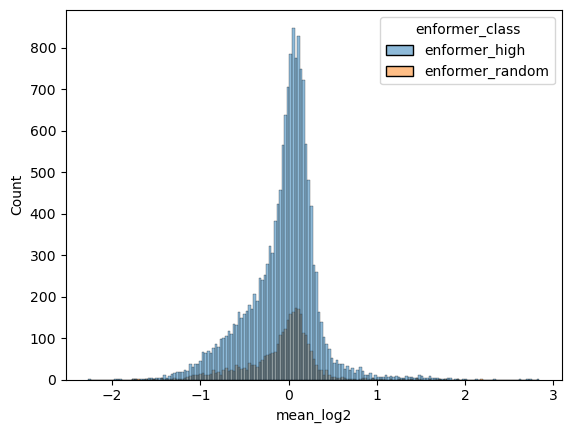

In [14]:
sns.histplot(data=enformer_counts_high_vs_random, x="mean_log2", hue="enformer_class")


<Axes: xlabel='mean_log2', ylabel='Count'>

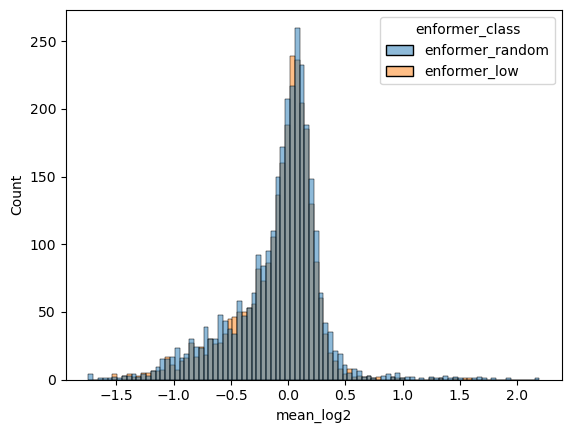

In [15]:
# plot low vs random 
sns.histplot(data=enformer_counts_low_vs_random, x="mean_log2", hue="enformer_class")

#### Möglichkeit: suche dir nun neuro spezifische varianten raus: hat es dort einfluss? 

In [81]:
enformer_mprasnakeflow.columns

Index(['chrom', 'pos', 'id', 'ref', 'alt', 'DNase_max', 'max_col', 'CHROM',
       'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'variant_type',
       'gene_type_list', 'enformer_class', 'chr_pos_ref_alt', 'condition',
       'name', 'replicates', 'dna_counts', 'rna_counts', 'dna_normalized',
       'rna_normalized', 'ratio', 'log2', 'mean_dna_counts', 'mean_rna_counts',
       'mean_dna_normalized', 'mean_rna_normalized', 'mean_ratio', 'mean_log2',
       'mean_n_obs_bc', 'name_without_group'],
      dtype='object')

In [17]:
enformer_mprasnakeflow_neuro = enformer_mprasnakeflow.loc[enformer_mprasnakeflow['gene_type_list'].apply(lambda gene_type_list: "neuro" in gene_type_list)]
enformer_mprasnakeflow_neuro # 6605


,chrom,pos,id,ref,alt,DNase_max,max_col,CHROM,POS,ID,...,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,mean_n_obs_bc,name_without_group
3,chr12,2616967,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,2754.770500,401_DNASE:common myeloid,chr12,2616967.0,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,...,0.774487,-0.368686,71.000000,127.333333,0.092662,0.071243,0.800829,-0.329823,28.0,ALT_CACNA1C|ENSG00000151067.23|EH38E2998634_fw...
11,chr12,2342052,CACNA1C|ENSG00000151067.23|EH38E1587027|12-234...,G,C,1770.119800,392_DNASE:CD14-positive,chr12,2342052.0,CACNA1C|ENSG00000151067.23|EH38E1587027|12-234...,...,0.978143,-0.031883,94.333333,213.666667,0.122532,0.119948,1.018474,0.020055,28.0,ALT_CACNA1C|ENSG00000151067.23|EH38E1587027_fw...
14,chr12,116324234,MED13L|ENSG00000123066.9|EH38E3043756|12-11632...,G,A,1692.079500,392_DNASE:CD14-positive,chr12,116324234.0,MED13L|ENSG00000123066.9|EH38E3043756|12-11632...,...,1.157772,0.211351,233.000000,624.666667,0.147137,0.170388,1.201022,0.259667,58.0,ALT_MED13L|ENSG00000123066.9|EH38E3043756_rev_...
17,chr17,31414161,NF1|ENSG00000196712.20|EH38E3217473|17-3141416...,G,A,1683.679000,392_DNASE:CD14-positive,chr17,31414161.0,NF1|ENSG00000196712.20|EH38E3217473|17-3141416...,...,1.082842,0.114823,67.000000,168.000000,0.114056,0.122605,1.114372,0.152995,21.0,ALT_NF1|ENSG00000196712.20|EH38E3217473_fwd_ti...
40,chr17,17663845,RAI1|ENSG00000108557.20|EH38E3212056|17-176638...,T,A,1427.099700,392_DNASE:CD14-positive,chr17,17663845.0,RAI1|ENSG00000108557.20|EH38E3212056|17-176638...,...,0.843776,-0.245068,180.666667,353.000000,0.120098,0.101131,0.872514,-0.198460,55.0,ALT_RAI1|ENSG00000108557.20|EH38E3212056_fwd_t...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18350,chr1,43454876,SZT2|ENSG00000198198.17|EH38E2807393|1-4345487...,G,A,-2.065445,24_DNASE:HeLa-S3 treate,chr1,43454876.0,SZT2|ENSG00000198198.17|EH38E2807393|1-4345487...,...,0.982454,-0.025539,426.666667,970.666667,0.125475,0.123284,1.017242,0.023065,125.0,ALT_SZT2|ENSG00000198198.17|EH38E2807393_fwd_t...
18351,chr13,114353586,CHAMP1|ENSG00000198824.8|EH38E3085024|13-11435...,G,T,-3.867383,245_DNASE:upper lobe of,chr13,114353586.0,CHAMP1|ENSG00000198824.8|EH38E3085024|13-11435...,...,0.775399,-0.366988,89.666667,161.000000,0.123265,0.095624,0.801113,-0.319985,27.0,ALT_CHAMP1|ENSG00000198824.8|EH38E3085024_fwd_...
18352,chr13,114353589,CHAMP1|ENSG00000198824.8|EH38E3085024|13-11435...,C,T,-4.061413,10_DNASE:H54,chr13,114353589.0,CHAMP1|ENSG00000198824.8|EH38E3085024|13-11435...,...,1.135947,0.183896,46.000000,121.000000,0.104752,0.118243,1.179158,0.232633,16.0,ALT_CHAMP1|ENSG00000198824.8|EH38E3085024_fwd_...
18353,chr13,114353565,CHAMP1|ENSG00000198824.8|EH38E3085024|13-11435...,G,A,-4.372175,550_DNASE:right kidney m,chr13,114353565.0,CHAMP1|ENSG00000198824.8|EH38E3085024|13-11435...,...,0.767729,-0.381330,66.000000,117.333333,0.108995,0.083537,0.794999,-0.334253,22.0,ALT_CHAMP1|ENSG00000198824.8|EH38E3085024_fwd_...


In [18]:
enformer_counts_neuro_high_vs_random = enformer_mprasnakeflow_neuro.loc[enformer_mprasnakeflow_neuro['enformer_class'].isin(['enformer_high', 'enformer_random'])]
print(enformer_counts_neuro_high_vs_random.shape[0]) # 5781

enformer_counts_neuro_low_vs_random = enformer_mprasnakeflow_neuro.loc[enformer_mprasnakeflow_neuro['enformer_class'].isin(['enformer_low', 'enformer_random'])]
print(enformer_counts_neuro_low_vs_random.shape[0])# 1659

5781
1659


<Axes: xlabel='mean_log2', ylabel='Count'>

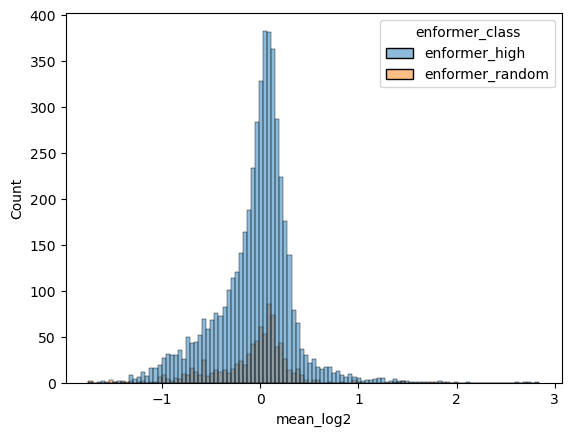

In [19]:
sns.histplot(data=enformer_counts_neuro_high_vs_random, x="mean_log2", hue="enformer_class")


<Axes: xlabel='mean_log2', ylabel='Count'>

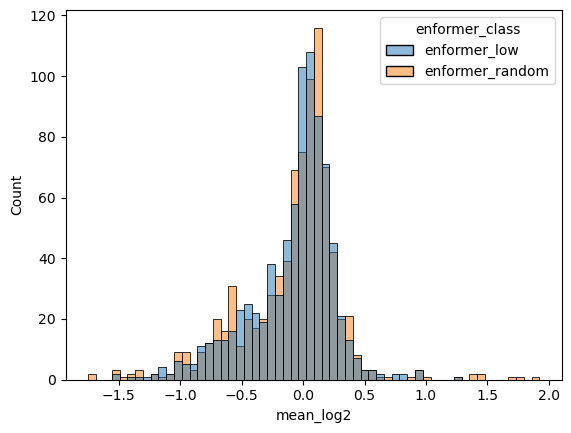

In [20]:
sns.histplot(data=enformer_counts_neuro_low_vs_random, x="mean_log2", hue="enformer_class")


Load result from MPRAsnakeflow (count table with at least 10 barcodes)